pythonコードとしては、FDM2D_2nd_homo.pyとしてまとめているが、コードをブロックごとに確認して内容を理解するためにnotebookに書き起こした。

以下、それぞれのブロックごとに解説をしていく。

In [11]:
import numpy as np
import os

# 領域設定など
SP = np.float32
NX, NZ = 400, 400
DX, DZ = 0.4, 0.4
DT = 0.02
NTMAX = 2000

ここでは計算領域や格子間隔などの設定を実施している。ご存知のように数値計算自体は、慣例的に使われている単位で計算されていることが多く、ここでは格子間隔DXやDZはkm、DTは秒を採用している。

NX = NZ = 400なので、160 km四方の面上の地震波伝播を2000ステップ（４０秒間）分計算を実施している。

In [12]:
# 震源情報
I0, K0 = NX // 2, NZ // 2
T0, TS = 5.0, 0.0
MXX, MZZ, MXZ, MO = 0.0, 0.0, 1.0, 1.0
DTXZ = DT / (DX * DZ)

ここでは震源について記述されている。領域の中心に$m_xz=1$のメカニズム解を持つ震源を設定した。その震源時間関数は、$T_S = 0$秒で開始し、$T_0 = 4$秒の破壊継続時間を持つ。

この計算コードでは、震源をStress Glut（e.g., Coutant et al. 1995）を用いて実装しています。2次元P-SV問題の場合、具体的に震源による応力の変化分は、
$$
\Delta \sigma_{xx}^{N} = -\frac{\dot{M}_{xx}^{N-1/2}}{\Delta x\Delta z}\Delta t　\\
\Delta \sigma_{zz}^{N} = -\frac{\dot{M}_{zz}^{N-1/2}}{\Delta x\Delta z}\Delta t　\\
\Delta \sigma_{xz}^{N} = -\frac{\dot{M}_{xz}^{N-1/2}}{\Delta x\Delta z}\Delta t
$$
と記述することができ、それをコードに実装しています。$\dot{M}^{N-1/2}$はN-1/2タイムステップの震源時間関数（モーメントレート関数）の値となります。最終的に、震源位置での応力場へ$\Delta \sigma_{pq}^{N}$を足して更新することで、実現されます。つまり、
$$
\sigma_{xx}^{N} \gets \sigma_{xx}^{N} - \frac{\dot{M}_{xx}^{N-1/2}}{\Delta x\Delta z}\Delta t　\\
\sigma_{zz}^{N} \gets \sigma_{zz}^{N} - \frac{\dot{M}_{zz}^{N-1/2}}{\Delta x\Delta z}\Delta t　\\
\sigma_{xz}^{N} \gets \sigma_{xz}^{N} - \frac{\dot{M}_{xz}^{N-1/2}}{\Delta x\Delta z}\Delta t　
$$
となります。この震源の記述は、時間ループ内に埋め込まれています（後で登場）。

In [13]:
# 出力設定
NTDEC = 50
NXD, NZD = 2, 2 # 出力波動場の空間間引き
ONAME0 = "output/psv.h."

数値計算の結果を可視化するために、計算結果を出力するわけですが2次元断面とはいえ、計算した結果をすべて出力するとファイルが重たくなってしまうので、時間については50ステップ毎に、空間については2格子毎に間引いて出力するように実装しています。

（講義内ではわかりやすさのためにASCIIデータを出力しているが、バイナリ形式で数値計算結果を保存することが多い。）

In [14]:
# --- 関数定義 ---
def kupper(t, ts, tr):
    if ts <= t <= ts + tr:
        return 3 * np.pi * (np.sin(np.pi * (t - ts) / tr))**3 / (4 * tr)
    else:
        return 0.0

# 配列の初期化 0~NX+1
SXX = np.zeros((NX + 2, NZ + 2), dtype=SP)
SZZ = np.zeros((NX + 2, NZ + 2), dtype=SP)
SXZ = np.zeros((NX + 2, NZ + 2), dtype=SP)
VX  = np.zeros((NX + 2, NZ + 2), dtype=SP)
VZ  = np.zeros((NX + 2, NZ + 2), dtype=SP)

# 均質媒質
VP, VS, RO = 6.0, 3.5, 2.3
RIG_val = RO * VS**2
LAM_val = RO * VP**2 - 2.0 * RO * VS**2

# 各格子点に物性を割り当て
RIG = np.full((NX + 2, NZ + 2), RIG_val, dtype=SP)
LAM = np.full((NX + 2, NZ + 2), LAM_val, dtype=SP)
RHO = np.full((NX + 2, NZ + 2), RO, dtype=SP)

地下構造を設定しています。今回は無限均質媒質なので、numpyの機能を用いて配列内の数値を決めています。地震波伝播シミュレーションでは、$V_P$、$V_S$ [km/s]や$\rho$ [g/$\mathrm{cm}^{3}$]といった物理量を与え、運動方程式を解くのに必要なラメの係数（$\lambda$と$\mu$）へ変換して媒質の物性を表します。

ここまでの物性値の準備を経て、以下のループによって地震波伝播の時間発展を計算する。Pythonは多重ループを用いると、途端に速度が遅くなるので、スライス表記にて空間のループを書いています。

例：
```
    dxvx = (VX[1:NX+1, 1:NZ+1] - VX[0:NX, 1:NZ+1]) / DX
    dxvz = (VZ[2:NX+2, 1:NZ+1] - VZ[1:NX+1, 1:NZ+1]) / DX
    dzvx = (VX[1:NX+1, 2:NZ+2] - VX[1:NX+1, 1:NZ+1]) / DZ
    dzvz = (VZ[1:NX+1, 1:NZ+1] - VZ[1:NX+1, 0:NZ]) / DZ
```

In [15]:
# 出力ディレクトリの指定
os.makedirs("output", exist_ok=True)

# メインループ
print(f"{'Step':>5} / {NTMAX}: {'Time':>7} {'Vxmax':>12}")
for it in range(1, NTMAX + 1):
    T = it * DT

    # 1. 応力場の更新
    dxvx = (VX[1:NX+1, 1:NZ+1] - VX[0:NX, 1:NZ+1]) / DX
    dxvz = (VZ[2:NX+2, 1:NZ+1] - VZ[1:NX+1, 1:NZ+1]) / DX
    dzvx = (VX[1:NX+1, 2:NZ+2] - VX[1:NX+1, 1:NZ+1]) / DZ
    dzvz = (VZ[1:NX+1, 1:NZ+1] - VZ[1:NX+1, 0:NZ]) / DZ

    lam_v, rig_v = LAM[1:NX+1, 1:NZ+1], RIG[1:NX+1, 1:NZ+1]
    SXX[1:NX+1, 1:NZ+1] += ((lam_v + 2.0*rig_v) * dxvx + lam_v * dzvz) * DT
    SZZ[1:NX+1, 1:NZ+1] += ((lam_v + 2.0*rig_v) * dzvz + lam_v * dxvx) * DT
    SXZ[1:NX+1, 1:NZ+1] += rig_v * (dxvz + dzvx) * DT

    # 震源注入
    sdrop = MO * kupper(T, TS, T0) * DTXZ
    SXX[I0, K0] -= MXX * sdrop
    SZZ[I0, K0] -= MZZ * sdrop
    SXZ[I0-1:I0+1, K0-1:K0+1] -= MXZ * sdrop * 0.25

    # 2. 速度場の更新
    dxsxx = (SXX[2:NX+2, 1:NZ+1] - SXX[1:NX+1, 1:NZ+1]) / DX
    dxsxz = (SXZ[1:NX+1, 1:NZ+1] - SXZ[0:NX, 1:NZ+1]) / DX
    dzszz = (SZZ[1:NX+1, 2:NZ+2] - SZZ[1:NX+1, 1:NZ+1]) / DZ
    dzsxz = (SXZ[1:NX+1, 1:NZ+1] - SXZ[1:NX+1, 0:NZ]) / DZ

    VX[1:NX+1, 1:NZ+1] += (dxsxx + dzsxz) / RHO[1:NX+1, 1:NZ+1] * DT
    VZ[1:NX+1, 1:NZ+1] += (dxsxz + dzszz) / RHO[1:NX+1, 1:NZ+1] * DT

    # 進捗表示とスナップショット出力
    if it % NTDEC == 0:
        vxmax = np.max(VX)
        print(f"{it:5d}/{NTMAX:5d}: T={T:6.2f}[s] vxmax={vxmax:.3e}")
        
        # 空間データ一括計算
        i_idx, k_idx = np.arange(1, NX+1, NXD), np.arange(1, NZ+1, NZD)
        ii, kk = np.meshgrid(i_idx, k_idx, indexing='ij')
        
        # 物理量の計算 (div, rot)
        d_vx_x = (VX[ii, kk] - VX[ii-1, kk]) / DX
        d_vz_z = (VZ[ii, kk] - VZ[ii, kk-1]) / DZ
        d_vx_z = (VX[ii, kk+1] - VX[ii, kk]) / DZ
        d_vz_x = (VZ[ii+1, kk] - VZ[ii, kk]) / DX
        
        out_data = np.column_stack([
            ((ii-1)*DX).ravel(), ((kk-1)*DZ).ravel(),
            VX[ii, kk].ravel(), VZ[ii, kk].ravel(),
            (d_vx_x + d_vz_z).ravel(), (d_vz_x - d_vx_z).ravel()
        ])
        np.savetxt(f"{ONAME0}{it:05d}.out", out_data, fmt='%9.3f %9.3f %12.3e %12.3e %12.3e %12.3e')


 Step / 2000:    Time        Vxmax
   50/ 2000: T=  1.00[s] vxmax=6.636e-04
  100/ 2000: T=  2.00[s] vxmax=2.927e-03
  150/ 2000: T=  3.00[s] vxmax=2.915e-03
  200/ 2000: T=  4.00[s] vxmax=6.336e-04
  250/ 2000: T=  5.00[s] vxmax=3.154e-04
  300/ 2000: T=  6.00[s] vxmax=3.087e-04
  350/ 2000: T=  7.00[s] vxmax=3.018e-04
  400/ 2000: T=  8.00[s] vxmax=2.914e-04
  450/ 2000: T=  9.00[s] vxmax=2.791e-04
  500/ 2000: T= 10.00[s] vxmax=2.663e-04
  550/ 2000: T= 11.00[s] vxmax=2.545e-04
  600/ 2000: T= 12.00[s] vxmax=2.440e-04
  650/ 2000: T= 13.00[s] vxmax=2.345e-04
  700/ 2000: T= 14.00[s] vxmax=2.259e-04
  750/ 2000: T= 15.00[s] vxmax=2.179e-04
  800/ 2000: T= 16.00[s] vxmax=2.104e-04
  850/ 2000: T= 17.00[s] vxmax=2.033e-04
  900/ 2000: T= 18.00[s] vxmax=1.976e-04
  950/ 2000: T= 19.00[s] vxmax=1.967e-04
 1000/ 2000: T= 20.00[s] vxmax=1.954e-04
 1050/ 2000: T= 21.00[s] vxmax=1.889e-04
 1100/ 2000: T= 22.00[s] vxmax=1.847e-04
 1150/ 2000: T= 23.00[s] vxmax=1.817e-04
 1200/ 2000: T= 24.00[

ディレクトリoutput以下に、地震波動場が出力されているので、以下で、可視化して計算結果を見ていきます。可視化の際に、$v_x$と$v_z$と速度の$x$と$z$成分以外に、
$$
\nabla \cdot \boldsymbol{v} \\
\nabla \times \boldsymbol{v}
$$
の計算をしています。これは、発散$\nabla \cdot$と回転$\nabla \times$をとることで体積変化の成分と回転成分に波動場を分けていて、前者がP波、後者がS波に対応します。出力ファイル名がpsv.h.00100.outなどになっていますが、1ステップあたりの時間刻みが0.02秒ですので、psv.h.00100.outは2秒後の地震波動場の情報が書き出されています。

以下、10秒後（00500ステップ）の地震波場を可視化する。

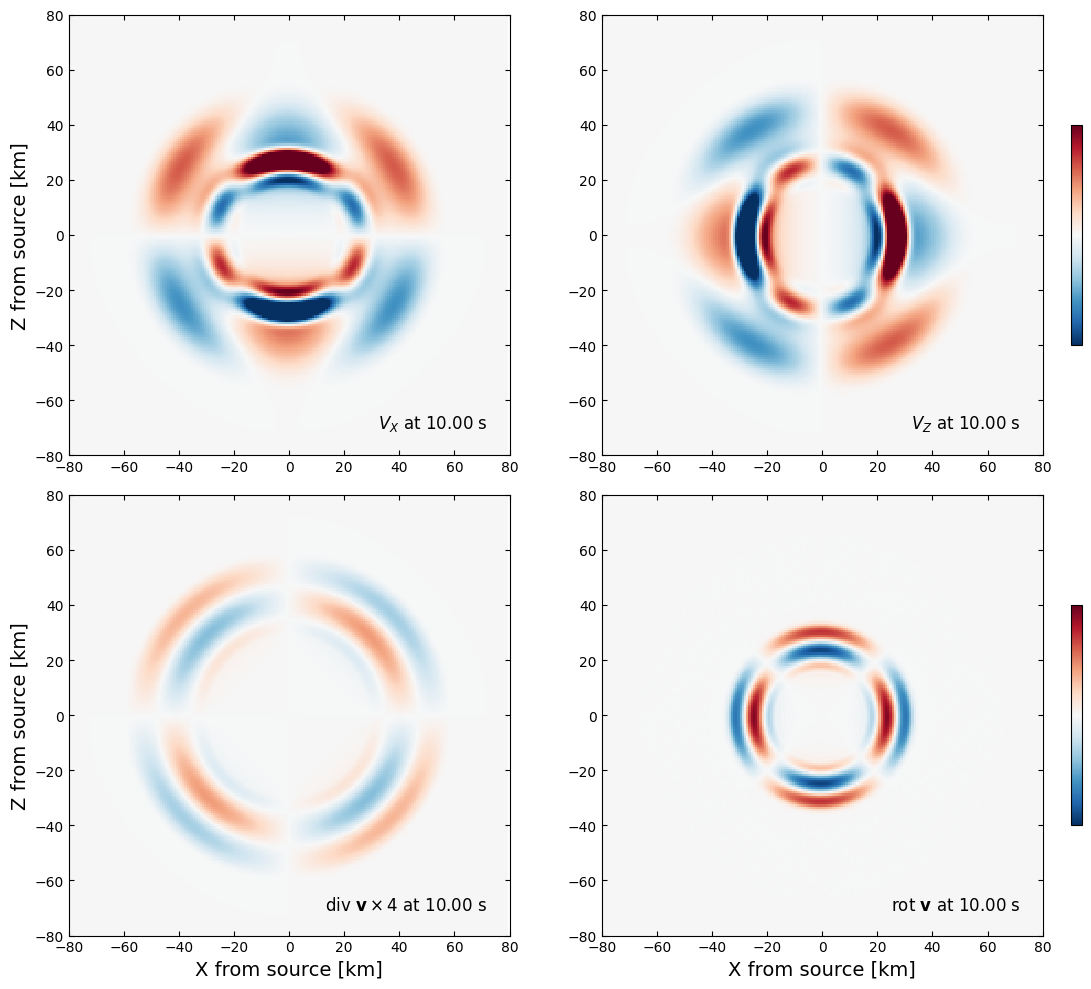

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# --- 設定 ---
fact = 1e4 # scale factor
NX, NZ = 400 // 2, 400 // 2  # 格子数を空間的に間引いた

time_val = 10.0
step = int(time_val/DT) # DTが中途半端な値の時のために調整処理
step = int(step/100)*100
time_val = step*DT
filename = f"output/psv.h.{step:05d}.out"

# データ読み込み
out = pd.read_csv(filename, sep='\s+', names=('X','Z','VX','VZ','div','rot'))
    

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
plt.rcParams.update({'font.size': 10})
    
# データ整形
X = out['X'].values.reshape(NZ, NX)-80
Z = out['Z'].values.reshape(NZ, NX)-80
VX = out['VX'].values.reshape(NZ, NX)
VZ = out['VZ'].values.reshape(NZ, NX)
VP = out['div'].values.reshape(NZ, NX)
VS = out['rot'].values.reshape(NZ, NX)
    
# 正規化
VX *= fact
VZ *= fact
VP *= fact*4
VS *= fact

# 左側：Vx
ax0 = axs[0,0]
im1 = ax0.pcolormesh(X, Z, VX, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
label_text = fr"$V_X$ at {time_val:.2f} s"
ax0.text(0.95, 0.05, label_text,
        transform=ax0.transAxes,
        fontsize=12, va='bottom', ha='right', fontweight='regular')
ax0.set_ylabel('Z from source [km]',fontsize=14)

# 右側：Vz
ax1 = axs[0,1]
im2 = ax1.pcolormesh(X, Z, VZ, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
label_text = fr"$V_Z$ at {time_val:.2f} s"
ax1.text(0.95, 0.05, label_text,
        transform=ax1.transAxes,
        fontsize=12, va='bottom', ha='right', fontweight='regular')
fig.colorbar(im2, ax=ax1, shrink=0.5).set_ticks([])

# 左側：div v
ax0 = axs[1,0]
im1 = ax0.pcolormesh(X, Z, VP, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
label_text = fr"$\mathrm{{div}} \ \mathbf{{v}} \times 4$ at {time_val:.2f} s"
ax0.text(0.95, 0.05, label_text,
        transform=ax0.transAxes,
        fontsize=12, va='bottom', ha='right', fontweight='regular')
ax0.set_xlabel('X from source [km]',fontsize=14)
ax0.set_ylabel('Z from source [km]',fontsize=14)

# 右側：rot v
ax1 = axs[1,1]
im2 = ax1.pcolormesh(X, Z, VS, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
label_text = fr"$\mathrm{{rot}} \ \mathbf{{v}}$ at {time_val:.2f} s"
ax1.text(0.95, 0.05, label_text,
        transform=ax1.transAxes,
        fontsize=12, va='bottom', ha='right', fontweight='regular')
ax1.set_xlabel('X from source [km]',fontsize=14)
fig.colorbar(im2, ax=ax1, shrink=0.5).set_ticks([])

for ax in axs.flatten():
    ax.set_xlim(-80, 80)
    ax.set_ylim(-80, 80)
    ax.set_aspect(1.0)
    ax.tick_params(direction="in", top=True, right=True, which='both')

plt.tight_layout()
plt.show()

$v_x$と$v_z$と速度の$x$および$z$成分に加えて、発散$\nabla \cdot \mathbf{v}$と回転$\nabla \times \mathbf{v}$を描画した。どちらも-1~1の範囲できれいに描画できるようにスケールを調整し、発散については振幅を強調するために4倍した。

この計算では、$M_{xz} = 1$として震源を入力している。この場合、地震学的には震源から0º、90º、180º、270ºの方向へS波が強く輻射され、それと45ºずれた方向でP波が強く輻射される。実際に描画された地震波動場を観察してみる。

次に発震時刻（t = 0 [s]）からさらに時間が経過して20秒（01000ステップ）の地震波動場を可視化して観察してみる。

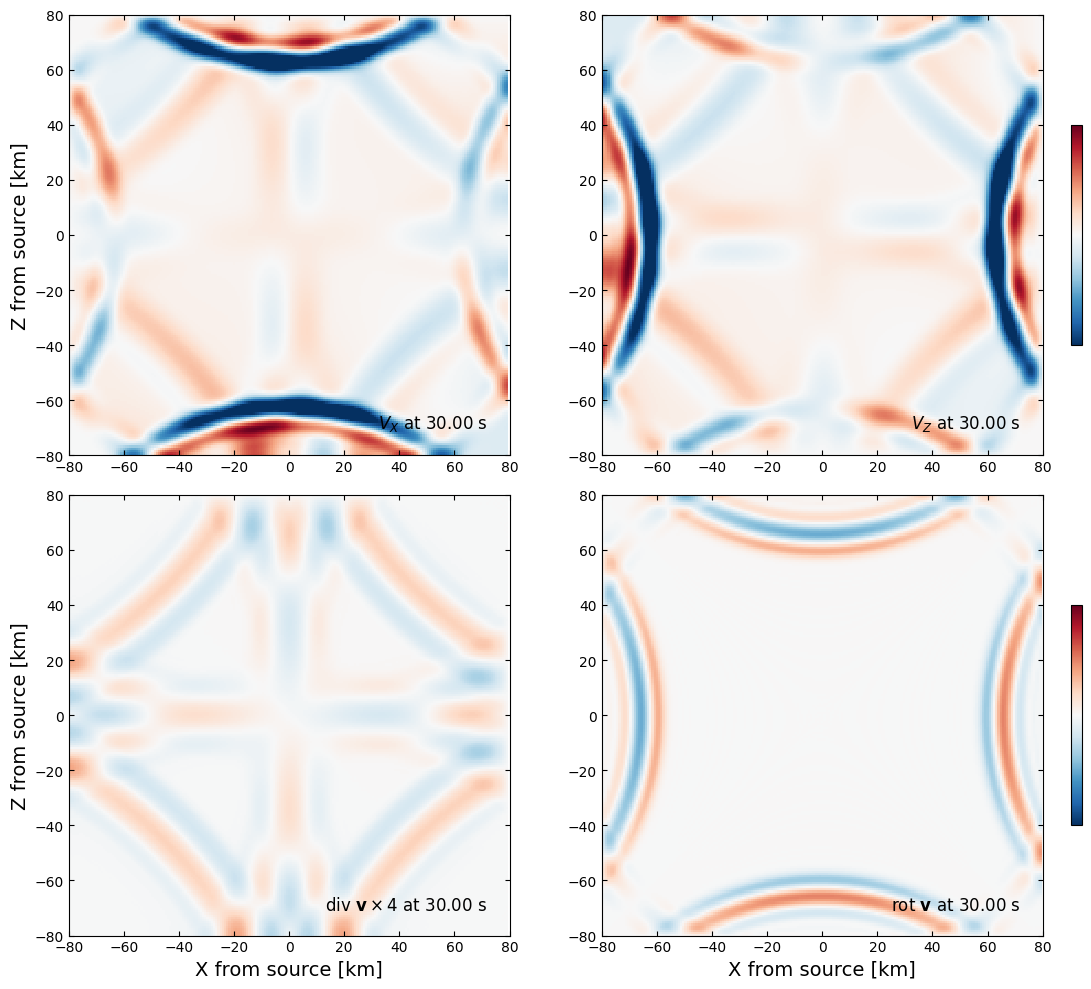

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# --- 設定 ---
fact = 1e4 # scale factor
NX, NZ = 400 // 2, 400 // 2  # 格子数を空間的に間引いた

time_val = 30.0
step = int(time_val/DT)
step = int(step/100)*100
time_val = step*DT
filename = f"output/psv.h.{step:05d}.out"

# データ読み込み
out = pd.read_csv(filename, sep='\s+', names=('X','Z','VX','VZ','div','rot'))
    

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
plt.rcParams.update({'font.size': 10})
    
# データ整形
X = out['X'].values.reshape(NZ, NX)-80
Z = out['Z'].values.reshape(NZ, NX)-80
VX = out['VX'].values.reshape(NZ, NX)
VZ = out['VZ'].values.reshape(NZ, NX)
VP = out['div'].values.reshape(NZ, NX)
VS = out['rot'].values.reshape(NZ, NX)
    
# 正規化
VX *= fact
VZ *= fact
VP *= fact*4
VS *= fact

# 左側：Vx
ax0 = axs[0,0]
im1 = ax0.pcolormesh(X, Z, VX, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
label_text = fr"$V_X$ at {time_val:.2f} s"
ax0.text(0.95, 0.05, label_text,
        transform=ax0.transAxes,
        fontsize=12, va='bottom', ha='right', fontweight='regular')
ax0.set_ylabel('Z from source [km]',fontsize=14)

# 右側：Vz
ax1 = axs[0,1]
im2 = ax1.pcolormesh(X, Z, VZ, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
label_text = fr"$V_Z$ at {time_val:.2f} s"
ax1.text(0.95, 0.05, label_text,
        transform=ax1.transAxes,
        fontsize=12, va='bottom', ha='right', fontweight='regular')
fig.colorbar(im2, ax=ax1, shrink=0.5).set_ticks([])

# 左側：div v
ax0 = axs[1,0]
im1 = ax0.pcolormesh(X, Z, VP, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
label_text = fr"$\mathrm{{div}} \ \mathbf{{v}} \times 4$ at {time_val:.2f} s"
ax0.text(0.95, 0.05, label_text,
        transform=ax0.transAxes,
        fontsize=12, va='bottom', ha='right', fontweight='regular')
ax0.set_xlabel('X from source [km]',fontsize=14)
ax0.set_ylabel('Z from source [km]',fontsize=14)

# 右側：rot v
ax1 = axs[1,1]
im2 = ax1.pcolormesh(X, Z, VS, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
label_text = fr"$\mathrm{{rot}} \ \mathbf{{v}}$ at {time_val:.2f} s"
ax1.text(0.95, 0.05, label_text,
        transform=ax1.transAxes,
        fontsize=12, va='bottom', ha='right', fontweight='regular')
ax1.set_xlabel('X from source [km]',fontsize=14)
fig.colorbar(im2, ax=ax1, shrink=0.5).set_ticks([])

for ax in axs.flatten():
    ax.set_xlim(-80, 80)
    ax.set_ylim(-80, 80)
    ax.set_aspect(1.0)
    ax.tick_params(direction="in", top=True, right=True, which='both')

plt.tight_layout()
plt.show()

P波速度が6 km/sですので、160 km四方の計算領域の（80 km, 80 km）に設定した震源ですので、震源から計算領域端までは、13.3秒で到達してしまいます。発震後20秒経過した地震波動場はどうなっているでしょうか？